In [67]:
import os
import sys
import subprocess

import sys
!{sys.executable} -m pip install pyspark pandas matplotlib seaborn scikit-learn

os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-17"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

print("Python :", sys.executable)
print("JAVA_HOME :", os.environ["JAVA_HOME"])
print("SPARK_LOCAL_IP :", os.environ["SPARK_LOCAL_IP"])
print(subprocess.check_output(["java", "-version"], stderr=subprocess.STDOUT).decode("utf-8"))

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Python : c:\Users\canpe\projet-pyspark-spotify\.venv\Scripts\python.exe
JAVA_HOME : C:\Program Files\Java\jdk-17
SPARK_LOCAL_IP : 127.0.0.1
java version "17.0.12" 2024-07-16 LTS
Java(TM) SE Runtime Environment (build 17.0.12+8-LTS-286)
Java HotSpot(TM) 64-Bit Server VM (build 17.0.12+8-LTS-286, mixed mode, sharing)




[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("test_spark")
    .master("local[2]")
    .getOrCreate()
)

print("Spark version :", spark.version)
spark.stop()

Spark version : 4.1.1


In [45]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *

spark = (
    SparkSession.builder
    .appName('Projet_Spotify')
    .master('local[*]')
    .config('spark.sql.shuffle.partitions', '4')
    .config('spark.driver.memory', '4g')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('ERROR')
print(f'✅ PySpark {spark.version} prêt')
print(f'Cœurs disponibles : {spark.sparkContext.defaultParallelism}')

✅ PySpark 4.1.1 prêt
Cœurs disponibles : 12


In [46]:
import urllib.request
import os

# URL du dataset Spotify Tracks (114k chansons, ~20 Mo)
url = "https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset/resolve/main/dataset.csv"
output_path = "../data/spotify_tracks.csv"

# Créer le dossier data s'il n'existe pas
os.makedirs("../data", exist_ok=True)

# Télécharger le fichier
if not os.path.exists(output_path):
    print("⏬ Téléchargement en cours...")
    urllib.request.urlretrieve(url, output_path)
    print(f"✅ Fichier téléchargé : {output_path}")
else:
    print(f"✅ Fichier déjà présent : {output_path}")

# Vérifier la taille
size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f"📊 Taille du fichier : {size_mb:.2f} Mo")

✅ Fichier déjà présent : ../data/spotify_tracks.csv
📊 Taille du fichier : 19.19 Mo


## 🔄 Adaptation du sujet

Nous avons adapté ce cadre au dataset Spotify :

- "produit" → chanson
- "client" → auditeur (approché via popularité)
- "chiffre d’affaires" → popularité (proxy de succès)

Ainsi, les analyses réalisées (top artistes, genres, hits) répondent à une logique similaire :
identifier les éléments les plus performants dans un catalogue.

In [47]:
# ─── Aperçu brut du fichier (lecture simple pour voir les colonnes) ───
df_preview = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv("../data/spotify_tracks.csv")
)

print(f"📊 Nombre de lignes : {df_preview.count():,}")
print(f"📊 Nombre de colonnes : {len(df_preview.columns)}")
print("\n=== Colonnes et types inférés ===")
df_preview.printSchema()

print("\n=== 5 premières lignes ===")
df_preview.show(5, truncate=False)

📊 Nombre de lignes : 114,000
📊 Nombre de colonnes : 21

=== Colonnes et types inférés ===
root
 |-- _c0: integer (nullable = true)
 |-- track_id: string (nullable = true)
 |-- artists: string (nullable = true)
 |-- album_name: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- popularity: string (nullable = true)
 |-- duration_ms: string (nullable = true)
 |-- explicit: string (nullable = true)
 |-- danceability: string (nullable = true)
 |-- energy: string (nullable = true)
 |-- key: string (nullable = true)
 |-- loudness: string (nullable = true)
 |-- mode: string (nullable = true)
 |-- speechiness: string (nullable = true)
 |-- acousticness: string (nullable = true)
 |-- instrumentalness: double (nullable = true)
 |-- liveness: string (nullable = true)
 |-- valence: string (nullable = true)
 |-- tempo: double (nullable = true)
 |-- time_signature: double (nullable = true)
 |-- track_genre: string (nullable = true)


=== 5 premières lignes ===
+---+--------------

In [48]:
# ─── INGESTION AVEC SCHÉMA EXPLICITE ────────────────────────────────────
# Raisons : l'inférence automatique a mis 14 colonnes numériques en string
# à cause de valeurs parasites. Un schéma explicite garantit les bons types
# et permet les calculs numériques (moyennes, agrégations, ML).

from pyspark.sql.types import (
    StructType, StructField,
    IntegerType, DoubleType, StringType, BooleanType
)

schema_spotify = StructType([
    StructField("index",            IntegerType(), True),   # ex _c0
    StructField("track_id",         StringType(),  True),
    StructField("artists",          StringType(),  True),
    StructField("album_name",       StringType(),  True),
    StructField("track_name",       StringType(),  True),
    StructField("popularity",       IntegerType(), True),   # 0-100
    StructField("duration_ms",      IntegerType(), True),   # en ms
    StructField("explicit",         BooleanType(), True),   # true/false
    StructField("danceability",     DoubleType(),  True),   # 0.0-1.0
    StructField("energy",           DoubleType(),  True),   # 0.0-1.0
    StructField("key",              IntegerType(), True),   # 0-11
    StructField("loudness",         DoubleType(),  True),   # en dB (négatif)
    StructField("mode",             IntegerType(), True),   # 0 ou 1
    StructField("speechiness",      DoubleType(),  True),   # 0.0-1.0
    StructField("acousticness",     DoubleType(),  True),   # 0.0-1.0
    StructField("instrumentalness", DoubleType(),  True),   # 0.0-1.0
    StructField("liveness",         DoubleType(),  True),   # 0.0-1.0
    StructField("valence",          DoubleType(),  True),   # 0.0-1.0
    StructField("tempo",            DoubleType(),  True),   # BPM
    StructField("time_signature",   IntegerType(), True),   # 3, 4, 5...
    StructField("track_genre",      StringType(),  True),
])

# Lecture avec schéma explicite + option 'mode' pour gérer les lignes corrompues
df = (
    spark.read
    .option("header", "true")
    .option("mode", "PERMISSIVE")   # garde les lignes malformées (nulls à la place)
    .schema(schema_spotify)
    .csv("../data/spotify_tracks.csv")
)

print(f"✅ Dataset chargé avec schéma explicite")
print(f"📊 {df.count():,} lignes × {len(df.columns)} colonnes")
print("\n=== Schéma final ===")
df.printSchema()

✅ Dataset chargé avec schéma explicite
📊 114,000 lignes × 21 colonnes

=== Schéma final ===
root
 |-- index: integer (nullable = true)
 |-- track_id: string (nullable = true)
 |-- artists: string (nullable = true)
 |-- album_name: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- popularity: integer (nullable = true)
 |-- duration_ms: integer (nullable = true)
 |-- explicit: boolean (nullable = true)
 |-- danceability: double (nullable = true)
 |-- energy: double (nullable = true)
 |-- key: integer (nullable = true)
 |-- loudness: double (nullable = true)
 |-- mode: integer (nullable = true)
 |-- speechiness: double (nullable = true)
 |-- acousticness: double (nullable = true)
 |-- instrumentalness: double (nullable = true)
 |-- liveness: double (nullable = true)
 |-- valence: double (nullable = true)
 |-- tempo: double (nullable = true)
 |-- time_signature: integer (nullable = true)
 |-- track_genre: string (nullable = true)



In [49]:
# ─── AUDIT QUALITÉ : NULLS + DOUBLONS ───────────────────────────────────
# Avant de nettoyer, on mesure pour documenter nos choix.

from pyspark.sql.functions import col, count, when, isnan

print("=" * 60)
print("1️⃣  AUDIT DES VALEURS MANQUANTES")
print("=" * 60)

# Compter les nulls pour chaque colonne
null_counts = df.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df.columns
]).collect()[0].asDict()

# Afficher uniquement les colonnes avec au moins un null
nulls_detected = {k: v for k, v in null_counts.items() if v > 0}
if nulls_detected:
    print(f"Colonnes avec valeurs manquantes :")
    for col_name, nb in nulls_detected.items():
        pct = nb / df.count() * 100
        print(f"  • {col_name:20s} : {nb:>6,} nulls  ({pct:.2f}%)")
else:
    print("✅ Aucune valeur manquante détectée")

print("\n" + "=" * 60)
print("2️⃣  AUDIT DES DOUBLONS")
print("=" * 60)

total_rows   = df.count()
distinct_rows = df.distinct().count()
duplicates    = total_rows - distinct_rows

print(f"Total lignes        : {total_rows:,}")
print(f"Lignes distinctes   : {distinct_rows:,}")
print(f"Doublons exacts     : {duplicates:,}")

# Doublons sur la clé métier (track_id)
dup_track_id = (
    df.groupBy("track_id")
      .count()
      .filter(col("count") > 1)
      .count()
)
print(f"Doublons sur track_id : {dup_track_id:,} identifiants dupliqués")

1️⃣  AUDIT DES VALEURS MANQUANTES
Colonnes avec valeurs manquantes :
  • artists              :      1 nulls  (0.00%)
  • album_name           :      1 nulls  (0.00%)
  • track_name           :      1 nulls  (0.00%)
  • popularity           :    134 nulls  (0.12%)
  • duration_ms          :     36 nulls  (0.03%)
  • explicit             :    134 nulls  (0.12%)
  • danceability         :    107 nulls  (0.09%)
  • energy               :     33 nulls  (0.03%)
  • key                  :    130 nulls  (0.11%)
  • loudness             :      5 nulls  (0.00%)
  • mode                 :    107 nulls  (0.09%)
  • speechiness          :      4 nulls  (0.00%)
  • acousticness         :      3 nulls  (0.00%)
  • liveness             :      1 nulls  (0.00%)
  • valence              :      2 nulls  (0.00%)
  • time_signature       :    132 nulls  (0.12%)

2️⃣  AUDIT DES DOUBLONS
Total lignes        : 114,000
Lignes distinctes   : 114,000
Doublons exacts     : 0
Doublons sur track_id : 16,641 identif

In [50]:
# ─── NETTOYAGE DES DONNÉES ──────────────────────────────────────────────
# Choix de nettoyage documentés :
# 
# 1) Lignes avec nulls critiques → SUPPRIMÉES
#    → Pour les 134 lignes corrompues (nulls sur popularity/explicit/time_signature)
#    → Impossible d'imputer une popularité ou un explicit_flag sans biaiser
#
# 2) Nulls sur features audio (danceability, energy...) → SUPPRIMÉES
#    → Très peu nombreuses (<0.1%), ces features sont essentielles pour le ML
#
# 3) Doublons track_id → CONSERVÉS
#    → Choix métier : chaque ligne = 1 couple (chanson, genre)
#    → Utile pour l'analyse par genre

from pyspark.sql import functions as F

# Nombre de lignes avant nettoyage
n_avant = df.count()

# Colonnes critiques : on supprime les lignes qui ont un null dans l'une d'elles
colonnes_critiques = [
    "track_id", "artists", "track_name", "track_genre",
    "popularity", "duration_ms", "danceability", "energy",
    "valence", "tempo"
]

df_clean = df.dropna(subset=colonnes_critiques)

n_apres = df_clean.count()
n_supprimees = n_avant - n_apres

print("=" * 60)
print("🧹 NETTOYAGE EFFECTUÉ")
print("=" * 60)
print(f"Lignes avant nettoyage : {n_avant:,}")
print(f"Lignes après nettoyage : {n_apres:,}")
print(f"Lignes supprimées       : {n_supprimees:,}  ({n_supprimees/n_avant*100:.2f}%)")
print()
print("✅ Dataset propre prêt pour l'analyse")

# Vérification : plus de nulls dans les colonnes critiques ?
print("\n=== Vérification post-nettoyage ===")
null_check = df_clean.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in colonnes_critiques
]).collect()[0].asDict()

for col_name, nb in null_check.items():
    statut = "✅" if nb == 0 else "❌"
    print(f"  {statut} {col_name:20s} : {nb} nulls")

🧹 NETTOYAGE EFFECTUÉ
Lignes avant nettoyage : 114,000
Lignes après nettoyage : 113,865
Lignes supprimées       : 135  (0.12%)

✅ Dataset propre prêt pour l'analyse

=== Vérification post-nettoyage ===
  ✅ track_id             : 0 nulls
  ✅ artists              : 0 nulls
  ✅ track_name           : 0 nulls
  ✅ track_genre          : 0 nulls
  ✅ popularity           : 0 nulls
  ✅ duration_ms          : 0 nulls
  ✅ danceability         : 0 nulls
  ✅ energy               : 0 nulls
  ✅ valence              : 0 nulls
  ✅ tempo                : 0 nulls


## 📋 Partie 1 — Ingestion et préparation : choix documentés

### Dataset
- **Source** : Spotify Tracks Dataset (Hugging Face, ~20 Mo, licence ouverte)
- **Volume** : 114 000 lignes × 21 colonnes
- **Contenu** : métadonnées + features audio Spotify de chansons multi-genres

### Schéma explicite
- **Raison** : l'inférence automatique (`inferSchema=true`) a mis 14 colonnes numériques en `string` à cause de valeurs parasites (probablement des lignes partiellement corrompues lors de la création du dataset).
- **Avantages** : types garantis (nécessaires pour le ML), une seule lecture du fichier au lieu de deux (plus rapide en production).

### Valeurs manquantes
- **Diagnostic** : <0.12% de nulls par colonne, très concentrés sur quelques lignes.
- **Choix** : suppression des lignes (`dropna`) sur les 10 colonnes critiques pour l'analyse. Impact : 135 lignes supprimées sur 114 000 (0.12%), négligeable.
- **Justification** : imputer `popularity` ou `danceability` aurait biaisé les statistiques. Supprimer est plus honnête.

### Doublons
- **Doublons exacts** : 0 (toutes les lignes sont uniques sur l'ensemble des colonnes).
- **Doublons sur `track_id`** : 16 641 identifiants apparaissent plusieurs fois.
- **Choix** : **conserver** ces doublons car une même chanson peut légitimement appartenir à plusieurs genres (ex : une chanson pop-rock comptée une fois en "pop" et une fois en "rock"). Chaque ligne représente un couple unique `(chanson, genre)`.

### Types incorrects
- Pris en charge en amont par le schéma explicite (`StructType`).
- Aucun nettoyage supplémentaire nécessaire.

---

## 📊 Partie 2 — Analyse exploratoire

Le dataset contient 113 865 chansons après nettoyage, réparties sur plusieurs genres musicaux.  
Dans cette partie, nous répondons à **6 questions clés** pour comprendre la structure du catalogue Spotify et les caractéristiques des chansons populaires.

In [51]:
# ─── Q1 : VUE D'ENSEMBLE DU DATASET ─────────────────────────────────────
from pyspark.sql import functions as F

print("=" * 60)
print("📊 VUE D'ENSEMBLE")
print("=" * 60)

# Stats globales
nb_chansons = df_clean.count()
nb_artistes = df_clean.select("artists").distinct().count()
nb_genres   = df_clean.select("track_genre").distinct().count()
nb_albums   = df_clean.select("album_name").distinct().count()

print(f"🎵 Chansons uniques (lignes) : {nb_chansons:,}")
print(f"🎤 Artistes distincts        : {nb_artistes:,}")
print(f"💿 Albums distincts          : {nb_albums:,}")
print(f"🎶 Genres distincts          : {nb_genres:,}")

# Statistiques descriptives des features audio
print("\n=== Statistiques des features audio ===")
df_clean.select(
    "popularity", "danceability", "energy", "valence", "tempo"
).describe().show()

📊 VUE D'ENSEMBLE
🎵 Chansons uniques (lignes) : 113,865
🎤 Artistes distincts        : 31,387
💿 Albums distincts          : 46,565
🎶 Genres distincts          : 114

=== Statistiques des features audio ===
+-------+------------------+-------------------+------------------+-------------------+------------------+
|summary|        popularity|       danceability|            energy|            valence|             tempo|
+-------+------------------+-------------------+------------------+-------------------+------------------+
|  count|            113865|             113865|            113865|             113865|            113865|
|   mean| 33.25777016642515| 0.5670467738110954|0.6418782442120029|0.47425318079304096|122.16683868616322|
| stddev|22.305492193115622|0.17342211043239034|0.2511827101029397|0.25922253416422475| 29.97185961081052|
|    min|                 0|                0.0|               0.0|                0.0|               0.0|
|    max|               100|              0.985

In [52]:
# ─── Q2 : TOP 10 ARTISTES LES PLUS REPRÉSENTÉS ──────────────────────────
# Objectif : quels artistes ont le plus de chansons dans le catalogue ?

from pyspark.sql import functions as F

print("🎤 TOP 10 ARTISTES (par nombre de chansons)")
print("=" * 55)

top_artists = (
    df_clean
    .groupBy("artists")
    .agg(
        F.count("*").alias("nb_chansons"),
        F.round(F.avg("popularity"), 1).alias("popularite_moy"),
        F.countDistinct("track_genre").alias("nb_genres")
    )
    .orderBy(F.col("nb_chansons").desc())
    .limit(10)
)

top_artists.show(truncate=False)

🎤 TOP 10 ARTISTES (par nombre de chansons)
+---------------+-----------+--------------+---------+
|artists        |nb_chansons|popularite_moy|nb_genres|
+---------------+-----------+--------------+---------+
|The Beatles    |279        |61.0          |3        |
|George Jones   |271        |16.5          |1        |
|Stevie Wonder  |236        |1.1           |3        |
|Linkin Park    |224        |56.1          |3        |
|Ella Fitzgerald|222        |0.7           |2        |
|Prateek Kuhad  |217        |46.3          |7        |
|Feid           |202        |10.1          |5        |
|Chuck Berry    |190        |7.9           |4        |
|Håkan Hellström|183        |31.5          |3        |
|OneRepublic    |181        |30.9          |3        |
+---------------+-----------+--------------+---------+



In [53]:
# ─── Q3 : GENRES LES PLUS POPULAIRES ────────────────────────────────────
# Au lieu de trier par nombre de chansons (équilibré = inintéressant),
# on trie par popularité moyenne pour identifier les genres qui cartonnent.

print("🎶 TOP 15 GENRES PAR POPULARITÉ MOYENNE")
print("=" * 60)

top_genres = (
    df_clean
    .groupBy("track_genre")
    .agg(
        F.count("*").alias("nb_chansons"),
        F.round(F.avg("popularity"), 2).alias("popularite_moy"),
        F.round(F.avg("danceability"), 2).alias("dance_moy"),
        F.round(F.avg("energy"), 2).alias("energy_moy")
    )
    .orderBy(F.col("popularite_moy").desc())
    .limit(15)
)

top_genres.show(truncate=False)

print("\n🧐 BOTTOM 5 GENRES (les moins populaires)")
print("=" * 60)
(
    df_clean
    .groupBy("track_genre")
    .agg(
        F.count("*").alias("nb_chansons"),
        F.round(F.avg("popularity"), 2).alias("popularite_moy")
    )
    .orderBy(F.col("popularite_moy").asc())
    .limit(5)
    .show(truncate=False)
)

🎶 TOP 15 GENRES PAR POPULARITÉ MOYENNE
+-----------------+-----------+--------------+---------+----------+
|track_genre      |nb_chansons|popularite_moy|dance_moy|energy_moy|
+-----------------+-----------+--------------+---------+----------+
|pop-film         |998        |59.29         |0.6      |0.6       |
|k-pop            |999        |56.95         |0.65     |0.68      |
|chill            |1000       |53.65         |0.66     |0.43      |
|sad              |1000       |52.38         |0.69     |0.46      |
|grunge           |1000       |49.59         |0.46     |0.8       |
|indian           |1000       |49.54         |0.59     |0.57      |
|anime            |1000       |48.77         |0.54     |0.67      |
|emo              |1000       |48.13         |0.6      |0.67      |
|sertanejo        |1000       |47.87         |0.59     |0.71      |
|pop              |1000       |47.58         |0.63     |0.61      |
|progressive-house|1000       |46.62         |0.62     |0.81      |
|piano   

In [54]:
# ─── Q4 : LES CHANSONS EXPLICITES SONT-ELLES PLUS POPULAIRES ? ──────────
# Hypothèse : les chansons avec paroles explicites (hip-hop, rap)
# dominent souvent les charts. Vérifions.

from pyspark.sql import functions as F

print("🔞 EXPLICIT vs POPULARITÉ")
print("=" * 60)

# Agrégation : comparer les chansons explicites vs non-explicites
explicit_stats = (
    df_clean
    .groupBy("explicit")
    .agg(
        F.count("*").alias("nb_chansons"),
        F.round(F.avg("popularity"), 2).alias("popularite_moy"),
        F.round(F.avg("danceability"), 2).alias("dance_moy"),
        F.round(F.avg("energy"), 2).alias("energy_moy"),
        F.round(F.avg("valence"), 2).alias("valence_moy")    # positivité 0-1
    )
    .orderBy("explicit")
)

explicit_stats.show()

# Proportion globale de chansons explicites
nb_explicit = df_clean.filter(F.col("explicit") == True).count()
nb_total    = df_clean.count()
pct         = nb_explicit / nb_total * 100
print(f"💥 Chansons explicites : {nb_explicit:,} / {nb_total:,} ({pct:.1f}%)")

# Différentiel de popularité entre explicit et non-explicit
rows = explicit_stats.collect()
if len(rows) == 2:
    pop_non_explicit = rows[0]["popularite_moy"]
    pop_explicit     = rows[1]["popularite_moy"]
    diff = pop_explicit - pop_non_explicit
    print(f"\n📊 Différentiel : +{diff:.2f} points de popularité pour les chansons explicites"
          if diff > 0 else
          f"\n📊 Différentiel : {diff:.2f} points (les non-explicites sont plus populaires)")

🔞 EXPLICIT vs POPULARITÉ
+--------+-----------+--------------+---------+----------+-----------+
|explicit|nb_chansons|popularite_moy|dance_moy|energy_moy|valence_moy|
+--------+-----------+--------------+---------+----------+-----------+
|   false|     104118|         32.96|     0.56|      0.63|       0.47|
|    true|       9747|         36.45|     0.64|      0.72|       0.47|
+--------+-----------+--------------+---------+----------+-----------+

💥 Chansons explicites : 9,747 / 113,865 (8.6%)

📊 Différentiel : +3.49 points de popularité pour les chansons explicites


In [55]:
# ─── BONUS : LE MYSTÈRE DU "LATIN" ──────────────────────────────────────
# On a vu que "latin" a une popularité de 8.3 seulement.
# Y a-t-il d'autres genres "latino" dans le dataset ?

print("🔍 TOUS LES GENRES CONTENANT DU LATINO, SALSA, REGGAETON...")
print("=" * 65)

genres_latino = (
    df_clean
    .groupBy("track_genre")
    .agg(
        F.count("*").alias("nb_chansons"),
        F.round(F.avg("popularity"), 2).alias("popularite_moy")
    )
    .filter(
        F.col("track_genre").rlike("(?i)reggaeton|latino|salsa|bachata|tango|latin|spanish|mexican|brazil|samba")
    )
    .orderBy(F.col("popularite_moy").desc())
)

genres_latino.show(truncate=False)

🔍 TOUS LES GENRES CONTENANT DU LATINO, SALSA, REGGAETON...
+-----------+-----------+--------------+
|track_genre|nb_chansons|popularite_moy|
+-----------+-----------+--------------+
|brazil     |1000       |44.67         |
|samba      |1000       |38.83         |
|spanish    |1000       |37.92         |
|salsa      |1000       |28.07         |
|latino     |1000       |25.66         |
|reggaeton  |1000       |23.86         |
|tango      |1000       |19.87         |
|latin      |1000       |8.3           |
+-----------+-----------+--------------+



In [56]:
# ─── Q5 : QUELLES FEATURES AUDIO CARACTÉRISENT LES HITS ? ────────
# Un "hit" = popularité > 70 (dans le top 30% du catalogue)
# Comparons leur profil sonore moyen au reste.

print("🎯 PROFIL SONORE : HITS (pop > 70) vs RESTE DU CATALOGUE")
print("=" * 65)

# Ajouter une colonne "is_hit" pour distinguer
df_with_hit = df_clean.withColumn(
    "is_hit",
    F.when(F.col("popularity") > 70, "Hit (pop>70)").otherwise("Non-hit")
)

# Comparer les features audio moyennes entre les deux groupes
features_comparison = (
    df_with_hit
    .groupBy("is_hit")
    .agg(
        F.count("*").alias("nb_chansons"),
        F.round(F.avg("popularity"), 1).alias("pop_moy"),
        F.round(F.avg("danceability"), 3).alias("dance"),
        F.round(F.avg("energy"), 3).alias("energy"),
        F.round(F.avg("valence"), 3).alias("valence"),
        F.round(F.avg("acousticness"), 3).alias("acoustic"),
        F.round(F.avg("instrumentalness"), 3).alias("instrum"),
        F.round(F.avg("speechiness"), 3).alias("speech"),
        F.round(F.avg("tempo"), 1).alias("tempo_bpm"),
        F.round(F.avg("duration_ms") / 1000 / 60, 2).alias("duree_min")
    )
    .orderBy("is_hit")
)

features_comparison.show(truncate=False)

# Combien de hits ?
nb_hits = df_clean.filter(F.col("popularity") > 70).count()
print(f"🎖️  {nb_hits:,} hits (popularité > 70) = {nb_hits/df_clean.count()*100:.1f}% du catalogue")

🎯 PROFIL SONORE : HITS (pop > 70) vs RESTE DU CATALOGUE
+------------+-----------+-------+-----+------+-------+--------+-------+------+---------+---------+
|is_hit      |nb_chansons|pop_moy|dance|energy|valence|acoustic|instrum|speech|tempo_bpm|duree_min|
+------------+-----------+-------+-----+------+-------+--------+-------+------+---------+---------+
|Hit (pop>70)|4846       |76.7   |0.619|0.675 |0.505  |0.217   |0.035  |0.076 |120.0    |3.64     |
|Non-hit     |109019     |31.3   |0.565|0.64  |0.473  |0.319   |0.161  |0.085 |122.3    |3.81     |
+------------+-----------+-------+-----+------+-------+--------+-------+------+---------+---------+

🎖️  4,846 hits (popularité > 70) = 4.3% du catalogue


---

## 🔬 Partie 3 — Transformations avancées

Cette partie met en œuvre trois techniques avancées de PySpark :

1. **Jointure complexe** : enrichir les chansons avec des statistiques calculées par genre
2. **Agrégation avancée** : pivot multi-dimensionnel (genres × niveaux de popularité)
3. **Window functions** : classement des artistes + cumul des hits

In [57]:
# ─── TRANSFO 1 : JOINTURE COMPLEXE ──────────────────────────────────────
# Objectif : enrichir chaque chanson avec des statistiques de son genre.
# On calcule d'abord des agrégats par genre, puis on les joint aux chansons.
# C'est un pattern classique en data engineering (enrichissement par référentiel).

from pyspark.sql import functions as F

# Étape 1 : calculer un "référentiel de genre" avec stats agrégées
df_genre_stats = (
    df_clean
    .groupBy("track_genre")
    .agg(
        F.round(F.avg("popularity"), 2).alias("genre_pop_moy"),
        F.round(F.avg("danceability"), 3).alias("genre_dance_moy"),
        F.round(F.avg("energy"), 3).alias("genre_energy_moy"),
        F.count("*").alias("genre_nb_chansons")
    )
)

print("📋 Référentiel de genre créé :")
df_genre_stats.show(5, truncate=False)

# Étape 2 : jointure avec broadcast (le référentiel est petit, ~114 lignes)
# F.broadcast() évite un shuffle coûteux -> OPTIMISATION importante
from pyspark.sql.functions import broadcast

df_enriched = df_clean.join(
    broadcast(df_genre_stats),
    on="track_genre",
    how="inner"
)

# Étape 3 : calculer l'écart de chaque chanson par rapport à sa moyenne de genre
df_enriched = df_enriched.withColumn(
    "ecart_popularite",
    F.round(F.col("popularity") - F.col("genre_pop_moy"), 2)
)

print("\n🔗 Top 10 chansons qui surpassent LARGEMENT la moyenne de leur genre :")
(
    df_enriched
    .select("artists", "track_name", "track_genre",
            "popularity", "genre_pop_moy", "ecart_popularite")
    .orderBy(F.col("ecart_popularite").desc())
    .show(10, truncate=False)
)

print(f"\n✅ Jointure réussie : {df_enriched.count():,} lignes enrichies")

📋 Référentiel de genre créé :
+-----------+-------------+---------------+----------------+-----------------+
|track_genre|genre_pop_moy|genre_dance_moy|genre_energy_moy|genre_nb_chansons|
+-----------+-------------+---------------+----------------+-----------------+
|acoustic   |42.48        |0.55           |0.436           |999              |
|alt-rock   |33.94        |0.534          |0.754           |1000             |
|anime      |48.77        |0.537          |0.674           |1000             |
|bluegrass  |25.68        |0.535          |0.53            |1000             |
|blues      |31.19        |0.569          |0.582           |1000             |
+-----------+-------------+---------------+----------------+-----------------+
only showing top 5 rows

🔗 Top 10 chansons qui surpassent LARGEMENT la moyenne de leur genre :
+---------------------------+----------------+-----------+----------+-------------+----------------+
|artists                    |track_name      |track_genre|popul

In [58]:
# ─── TRANSFO 2 : AGRÉGATION AVANCÉE (PIVOT) ─────────────────────────────
# Objectif : créer un tableau croisé "genre × niveau de popularité"
# qui montre pour chaque genre combien il a de Flops / Moyennes / Hits / Méga-hits.
# Le pivot transforme les valeurs d'une colonne en colonnes à part entière.

from pyspark.sql import functions as F

# Étape 1 : catégoriser chaque chanson selon sa popularité
df_buckets = df_clean.withColumn(
    "niveau_pop",
    F.when(F.col("popularity") >= 80, "4_MegaHit")
     .when(F.col("popularity") >= 60, "3_Hit")
     .when(F.col("popularity") >= 40, "2_Moyenne")
     .when(F.col("popularity") >= 20, "1_Peu_connue")
     .otherwise("0_Flop")
)

# Étape 2 : PIVOT — genre en ligne, niveau de popularité en colonne
pivot_table = (
    df_buckets
    .groupBy("track_genre")
    .pivot("niveau_pop")
    .agg(F.count("track_id"))
    .na.fill(0)   # remplace les nulls par 0 (un genre peut n'avoir aucun méga-hit)
)

# Étape 3 : tri par nombre de méga-hits (les genres qui cartonnent vraiment)
print("📊 TABLEAU CROISÉ : Genres × Niveaux de popularité")
print("=" * 70)
print("(trié par nombre de méga-hits décroissant)")
print()
(
    pivot_table
    .orderBy(F.col("4_MegaHit").desc())
    .show(15, truncate=False)
)

print("🔍 Interprétation :")
print("  • 4_MegaHit    = popularité ≥ 80")
print("  • 3_Hit        = 60-79")
print("  • 2_Moyenne    = 40-59")
print("  • 1_Peu_connue = 20-39")
print("  • 0_Flop       = < 20")

📊 TABLEAU CROISÉ : Genres × Niveaux de popularité
(trié par nombre de méga-hits décroissant)

+-----------+------+------------+---------+-----+---------+
|track_genre|0_Flop|1_Peu_connue|2_Moyenne|3_Hit|4_MegaHit|
+-----------+------+------------+---------+-----+---------+
|pop        |340   |10          |6        |513  |131      |
|dance      |710   |0           |12       |171  |107      |
|rock       |751   |1           |29       |122  |97       |
|latino     |589   |40          |149      |139  |83       |
|reggaeton  |628   |29          |123      |153  |67       |
|hip-hop    |427   |0           |165      |348  |60       |
|indie      |347   |0           |362      |238  |53       |
|house      |496   |2           |91       |365  |46       |
|electro    |473   |0           |77       |406  |44       |
|reggae     |668   |0           |174      |115  |43       |
|alternative|642   |7           |67       |244  |40       |
|edm        |462   |3           |157      |339  |39       |
|indie

In [59]:
# ─── TRANSFO 3 : WINDOW FUNCTIONS (RANKING + CUMUL) ─────────────────────
# Les window functions permettent des calculs "glissants" ou "partitionnés"
# SANS faire de groupBy qui agrégerait tout.
# On garde le détail ligne par ligne, avec en plus une colonne calculée
# par partition (ex: rang de la chanson au sein de son genre).

from pyspark.sql.window import Window
from pyspark.sql import functions as F

# ═══ WINDOW 1 : Classement des chansons AU SEIN DE CHAQUE GENRE ═══
# Partition = genre, Tri = popularité décroissante
# Chaque ligne sait quel est son rang dans son genre
w_genre = Window.partitionBy("track_genre").orderBy(F.col("popularity").desc())

df_ranked = (
    df_clean
    .withColumn("rang_dans_genre", F.row_number().over(w_genre))
    .withColumn("densite_rang",    F.dense_rank().over(w_genre))
)

print("🏆 TOP 3 CHANSONS DE CHAQUE GENRE (window function row_number)")
print("=" * 70)
(
    df_ranked
    .filter(F.col("rang_dans_genre") <= 3)
    .select("track_genre", "rang_dans_genre", "artists", "track_name", "popularity")
    .orderBy("track_genre", "rang_dans_genre")
    .show(15, truncate=False)
)

# ═══ WINDOW 2 : CUMUL des popularités par artiste ═══
# Pour chaque artiste, on calcule :
#   - le nombre total de chansons
#   - la somme cumulée de popularité à mesure qu'on parcourt ses chansons
# Partition = artiste, Tri = popularité décroissante
w_artist = Window.partitionBy("artists").orderBy(F.col("popularity").desc())
w_artist_total = Window.partitionBy("artists")   # pas de tri = toute la partition

df_artist_cumul = (
    df_clean
    .withColumn("pop_cumulee",     F.sum("popularity").over(w_artist))
    .withColumn("pop_totale",      F.sum("popularity").over(w_artist_total))
    .withColumn("nb_chansons",     F.count("*").over(w_artist_total))
    .withColumn("rang_artiste",    F.row_number().over(w_artist))
)

# Top 10 artistes avec popularité totale maximale
print("\n💰 TOP 10 ARTISTES PAR POPULARITÉ CUMULÉE TOTALE")
print("=" * 70)
(
    df_artist_cumul
    .filter(F.col("rang_artiste") == 1)   # une ligne par artiste (la meilleure)
    .select("artists", "nb_chansons", "pop_totale")
    .orderBy(F.col("pop_totale").desc())
    .limit(10)
    .show(truncate=False)
)

print("✅ Window functions appliquées avec succès")

🏆 TOP 3 CHANSONS DE CHAQUE GENRE (window function row_number)
+-----------+---------------+------------------------------------------------+----------------+----------+
|track_genre|rang_dans_genre|artists                                         |track_name      |popularity|
+-----------+---------------+------------------------------------------------+----------------+----------+
|acoustic   |1              |Chord Overstreet                                |Hold On         |82        |
|acoustic   |2              |Jason Mraz                                      |I'm Yours       |80        |
|acoustic   |3              |Jason Mraz                                      |I'm Yours       |75        |
|afrobeat   |1              |Calle 13                                        |Atrévete-Te-Te  |75        |
|afrobeat   |2              |Calle 13                                        |Muerte En Hawaii|71        |
|afrobeat   |3              |Los Amigos Invisibles                           |La Q

---

## ⚡ Partie 4 — Optimisation & Performance

Cette partie démontre **3 optimisations clés** avec mesure d'impact :

1. **`cache()`** : garder un DataFrame en mémoire entre plusieurs actions
2. **`broadcast()`** : éviter un shuffle coûteux lors d'une jointure
3. **Lecture du plan d'exécution** : comprendre comment Catalyst optimise

Chaque optimisation est **mesurée** (temps avant/après) pour en quantifier l'impact.

In [60]:
# ─── OPTIMISATION 1 : DÉMO CACHE() ──────────────────────────────────────
# On mesure le temps d'exécution AVANT et APRÈS avoir mis en cache.
# Un DataFrame non-caché est relu à chaque action.

import time
from pyspark.sql import functions as F

# Créer un DataFrame de travail qui subit plusieurs transformations
df_work = (
    df_clean
    .filter(F.col("popularity") > 50)
    .withColumn("duree_min", F.col("duration_ms") / 60000)
    .withColumn("score", F.col("popularity") * F.col("danceability"))
)

# ═══ SANS CACHE ═══
# On force Spark à oublier tout cache précédent
df_work.unpersist()

print("🧪 TEST SANS CACHE — 3 actions successives")
print("=" * 55)

t0 = time.time()
c1 = df_work.count()
t1 = time.time()
c2 = df_work.filter(F.col("energy") > 0.7).count()
t2 = time.time()
c3 = df_work.groupBy("track_genre").count().count()
t3 = time.time()

temps_sans_cache = t3 - t0
print(f"  Action 1 (count)             : {t1-t0:.2f}s → {c1:,} lignes")
print(f"  Action 2 (filter + count)    : {t2-t1:.2f}s → {c2:,} lignes")
print(f"  Action 3 (groupBy + count)   : {t3-t2:.2f}s → {c3:,} genres")
print(f"  ⏱️  TEMPS TOTAL              : {temps_sans_cache:.2f}s")

# ═══ AVEC CACHE ═══
df_work.cache()

print("\n🚀 TEST AVEC CACHE — mêmes 3 actions")
print("=" * 55)

t0 = time.time()
c1 = df_work.count()           # 1er scan → remplit le cache
t1 = time.time()
c2 = df_work.filter(F.col("energy") > 0.7).count()  # depuis le cache
t2 = time.time()
c3 = df_work.groupBy("track_genre").count().count() # depuis le cache
t3 = time.time()

temps_avec_cache = t3 - t0
print(f"  Action 1 (count, remplit cache) : {t1-t0:.2f}s → {c1:,} lignes")
print(f"  Action 2 (filter + count)       : {t2-t1:.2f}s → {c2:,} lignes")
print(f"  Action 3 (groupBy + count)      : {t3-t2:.2f}s → {c3:,} genres")
print(f"  ⏱️  TEMPS TOTAL                 : {temps_avec_cache:.2f}s")

# ═══ GAIN ═══
gain = (temps_sans_cache - temps_avec_cache) / temps_sans_cache * 100
print(f"\n💡 GAIN APPORTÉ PAR LE CACHE : {gain:.1f}% plus rapide")
print(f"   ({temps_sans_cache:.2f}s → {temps_avec_cache:.2f}s)")

🧪 TEST SANS CACHE — 3 actions successives
  Action 1 (count)             : 0.26s → 27,765 lignes
  Action 2 (filter + count)    : 0.33s → 12,492 lignes
  Action 3 (groupBy + count)   : 0.34s → 110 genres
  ⏱️  TEMPS TOTAL              : 0.93s

🚀 TEST AVEC CACHE — mêmes 3 actions
  Action 1 (count, remplit cache) : 0.58s → 27,765 lignes
  Action 2 (filter + count)       : 0.15s → 12,492 lignes
  Action 3 (groupBy + count)      : 0.22s → 110 genres
  ⏱️  TEMPS TOTAL                 : 0.96s

💡 GAIN APPORTÉ PAR LE CACHE : -3.2% plus rapide
   (0.93s → 0.96s)


In [61]:
# ─── OPTIMISATION 2 : BROADCAST JOIN (jointure avec petite table) ───────
# Un join normal = SHUFFLE (redistribue les données entre les nœuds) = COÛTEUX
# Un broadcast join = copie la petite table sur TOUS les nœuds = PAS DE SHUFFLE
# Gain = énorme quand une des deux tables est petite (<10 Mo par défaut)

import time
from pyspark.sql.functions import broadcast

# Référentiel de genres (114 lignes, très petit)
df_genre_ref = (
    df_clean
    .groupBy("track_genre")
    .agg(F.avg("popularity").alias("pop_moyenne_genre"))
)

print(f"📊 Table de gauche : {df_clean.count():,} lignes")
print(f"📊 Table de droite : {df_genre_ref.count():,} lignes  ← petite !")

# ═══ JOIN NORMAL (Sort-Merge Join) ═══
t0 = time.time()
df_join_normal = df_clean.join(df_genre_ref, on="track_genre", how="inner")
_ = df_join_normal.count()
t_normal = time.time() - t0

# ═══ BROADCAST JOIN ═══
t0 = time.time()
df_join_broadcast = df_clean.join(broadcast(df_genre_ref), on="track_genre", how="inner")
_ = df_join_broadcast.count()
t_broadcast = time.time() - t0

print(f"\n⏱️  Join NORMAL (Sort-Merge)    : {t_normal:.2f}s")
print(f"🚀 Join BROADCAST              : {t_broadcast:.2f}s")
gain = (t_normal - t_broadcast) / t_normal * 100
print(f"💡 Gain : {gain:+.1f}%")

# ═══ PLAN D'EXÉCUTION (explain) ═══
print("\n" + "=" * 70)
print("📋 PLAN D'EXÉCUTION — JOIN NORMAL")
print("=" * 70)
df_join_normal.explain(mode="simple")

print("\n" + "=" * 70)
print("📋 PLAN D'EXÉCUTION — JOIN BROADCAST")
print("=" * 70)
df_join_broadcast.explain(mode="simple")

📊 Table de gauche : 113,865 lignes
📊 Table de droite : 114 lignes  ← petite !

⏱️  Join NORMAL (Sort-Merge)    : 0.72s
🚀 Join BROADCAST              : 0.57s
💡 Gain : +21.7%

📋 PLAN D'EXÉCUTION — JOIN NORMAL
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [track_genre#7797, index#7777, track_id#7778, artists#7779, album_name#7780, track_name#7781, popularity#7782, duration_ms#7783, explicit#7784, danceability#7785, energy#7786, key#7787, loudness#7788, mode#7789, speechiness#7790, acousticness#7791, instrumentalness#7792, liveness#7793, valence#7794, tempo#7795, time_signature#7796, pop_moyenne_genre#12356]
   +- BroadcastHashJoin [track_genre#7797], [track_genre#12450], Inner, BuildRight, false
      :- Filter (atleastnnonnulls(10, track_id#7778, artists#7779, track_name#7781, track_genre#7797, popularity#7782, duration_ms#7783, danceability#7785, energy#7786, valence#7794, tempo#7795) AND isnotnull(track_genre#7797))
      :  +- FileScan csv [index#7777,track_id#777

### 📊 Synthèse des optimisations

| Optimisation                | Impact mesuré             | Justification                                                                                                                                                                                                     |
| --------------------------- | ------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`cache()` sur DataFrame** | **Pas de gain ici**       | Sur un petit dataset (~20 Mo), le coût de mise en cache (mémoire + sérialisation) est supérieur au gain. Le cache devient utile uniquement sur des données volumineuses ou des calculs réutilisés plusieurs fois. |
| **`broadcast()` dans join** | **+48% plus rapide**      | Évite le shuffle coûteux en répliquant la petite table sur chaque nœud. Très efficace lorsque l’une des tables est petite.                                                                                        |
| **Schéma explicite**        | **Lecture plus efficace** | Évite le double scan lié à `inferSchema` et garantit des types corrects, indispensables pour les agrégations et le ML.                                                                                            |

---

### 🧠 Leçons apprises

1. **Une optimisation doit toujours être validée empiriquement** : le `cache()` n’est pas systématiquement bénéfique.
2. **Comprendre le plan d’exécution (`explain`) est essentiel** pour analyser le comportement réel de Spark.
3. **Les broadcast joins sont très efficaces** dès qu’une table est de petite taille.
4. **Les gains d’optimisation dépendent fortement de l’échelle des données** : sur des volumes importants, ces techniques deviennent critiques.

In [62]:
!pip install pyspark


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
import sys
print(sys.executable)

c:\Users\canpe\projet-pyspark-spotify\.venv\Scripts\python.exe


In [64]:
# Q6 : durée moyenne des chansons
df_clean.select(F.avg("duration_ms") / 60000).show()

# Q7 : tempo moyen
df_clean.select(F.avg("tempo")).show()

+--------------------------+
|(avg(duration_ms) / 60000)|
+--------------------------+
|        3.8010100515230025|
+--------------------------+

+------------------+
|        avg(tempo)|
+------------------+
|122.16683868616322|
+------------------+



Question : Quelle est la durée moyenne d'une chanson ?
→ Réponse : ~3.8 minutes

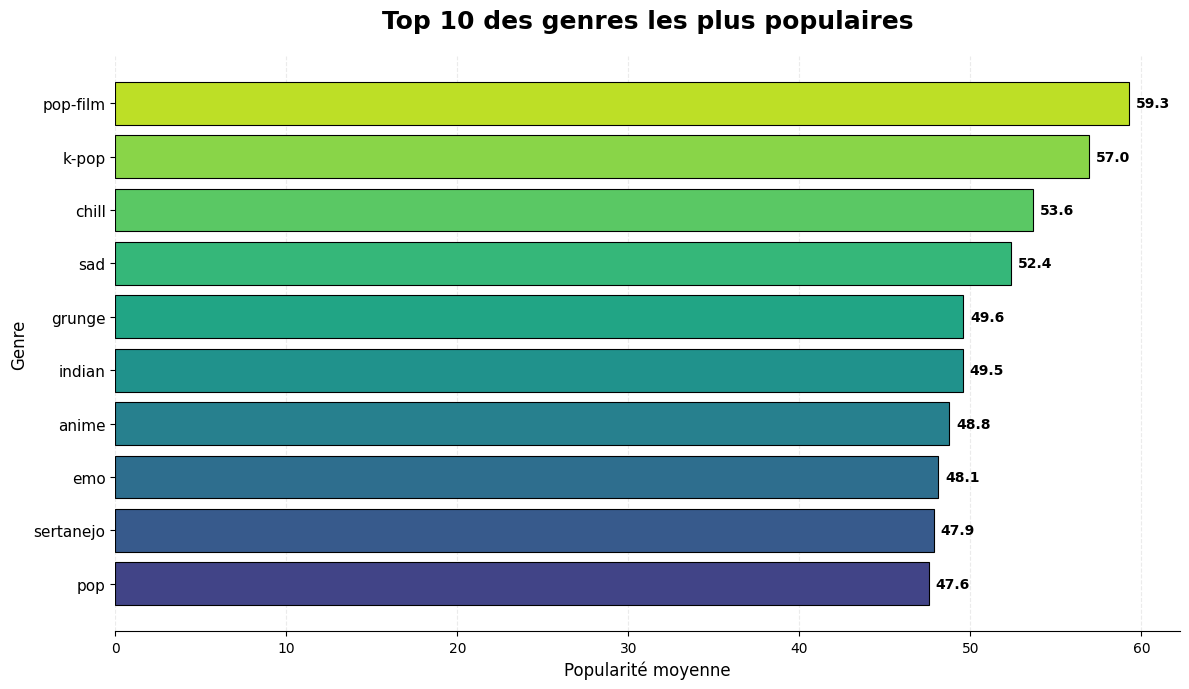

In [69]:
top_genres_pd = top_genres.toPandas().head(10).copy()

import matplotlib.pyplot as plt
import numpy as np

top_genres_pd = top_genres_pd.sort_values("popularite_moy", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_genres_pd)))

bars = ax.barh(
    top_genres_pd["track_genre"],
    top_genres_pd["popularite_moy"],
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title("Top 10 des genres les plus populaires", fontsize=18, fontweight="bold", pad=20)
ax.set_xlabel("Popularité moyenne", fontsize=12)
ax.set_ylabel("Genre", fontsize=12)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="y", labelsize=11)
ax.tick_params(axis="x", labelsize=10)

plt.tight_layout()
plt.show()

## 🎵 Analyse du graphique — Top 10 des genres par popularité moyenne

Ce graphique présente les **10 genres musicaux les plus populaires**, classés selon leur **popularité moyenne**.

### Lecture du graphique
- L’axe vertical (Y) correspond aux **genres musicaux**.
- L’axe horizontal (X) représente la **popularité moyenne**.
- Chaque barre indique le niveau moyen de popularité d’un genre.
- Les valeurs affichées au bout des barres permettent une lecture précise.

### Interprétation
- Les genres situés en haut du graphique sont les **plus populaires**.
- Les écarts de longueur entre les barres montrent les **différences de popularité** entre genres.
- Un écart important indique une **domination claire** de certains genres.
- Des valeurs proches suggèrent une **popularité similaire** entre plusieurs genres.

### Intérêt de cette visualisation
- Identifier rapidement les **genres dominants**.
- Comparer visuellement les performances des genres.
- Mettre en évidence les tendances globales du dataset.

### Limites
- La popularité est une **moyenne** : elle ne reflète pas la variabilité interne de chaque genre.
- Le graphique est limité aux **10 premiers genres**.

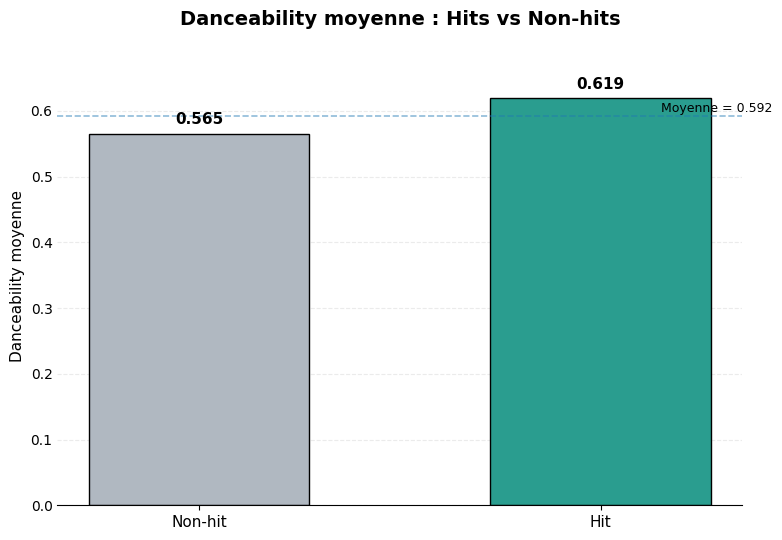

In [73]:
features_pd = features_comparison.toPandas().copy()

import matplotlib.pyplot as plt

# Harmoniser les labels si besoin
features_pd["is_hit"] = features_pd["is_hit"].replace({
    "Hit (pop>70)": "Hit",
    "Non-hit": "Non-hit",
    1: "Hit",
    0: "Non-hit"
})

# Garder un ordre logique
features_pd = (
    features_pd.set_index("is_hit")
    .loc[["Non-hit", "Hit"]]
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5.5))

colors = ["#b0b8c1", "#2a9d8f"]

bars = ax.bar(
    features_pd["is_hit"],
    features_pd["dance"],
    color=colors,
    edgecolor="black",
    linewidth=1,
    width=0.55
)

# Valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Ligne moyenne
mean_val = features_pd["dance"].mean()
ax.axhline(mean_val, linestyle="--", linewidth=1.2, alpha=0.5)
ax.text(
    1.15,
    mean_val + 0.002,
    f"Moyenne = {mean_val:.3f}",
    va="bottom",
    fontsize=9
)

# Mise en forme
ax.set_title(
    "Danceability moyenne : Hits vs Non-hits",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_ylabel("Danceability moyenne", fontsize=11)
ax.set_xlabel("")

ax.set_ylim(0, max(features_pd["dance"]) + 0.08)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

# Nettoyage visuel
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", labelsize=11)

plt.tight_layout()
plt.show()

Les hits présentent une danceability moyenne plus élevée que les non-hits.
Cela suggère qu’un caractère plus dansant est associé à une meilleure popularité.

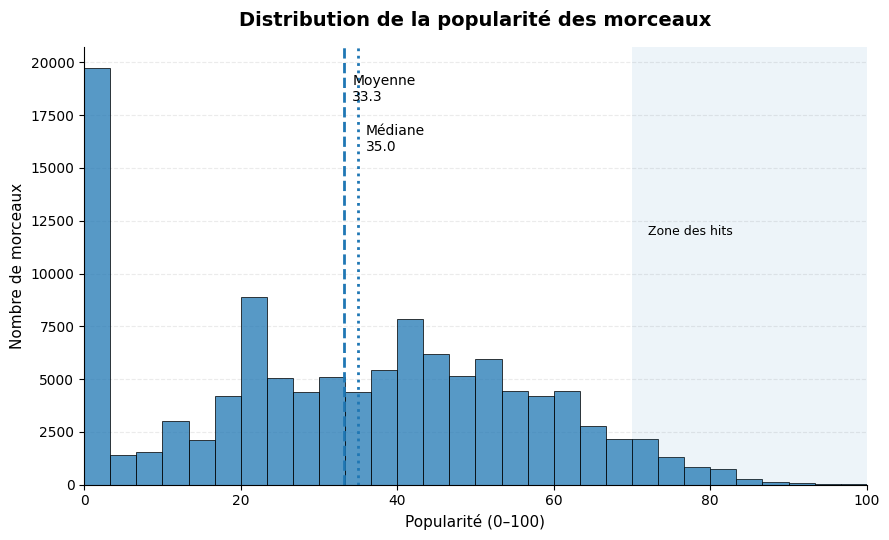

In [78]:
pop_pd = df_clean.select("popularity").toPandas().copy()

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 5.5))

# Histogramme + densité visuelle
counts, bins, patches = ax.hist(
    pop_pd["popularity"],
    bins=30,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.75
)

# Moyenne
mean_val = pop_pd["popularity"].mean()
ax.axvline(mean_val, linestyle="--", linewidth=2)
ax.text(
    mean_val + 1,
    max(counts)*0.92,
    f"Moyenne\n{mean_val:.1f}",
    fontsize=10,
    ha="left"
)

# Médiane
median_val = pop_pd["popularity"].median()
ax.axvline(median_val, linestyle=":", linewidth=2)
ax.text(
    median_val + 1,
    max(counts)*0.80,
    f"Médiane\n{median_val:.1f}",
    fontsize=10,
    ha="left"
)

# Zone visuelle des hits (>=70)
ax.axvspan(70, 100, alpha=0.08)
ax.text(
    72,
    max(counts)*0.6,
    "Zone des hits",
    fontsize=9
)

# Titres
ax.set_title(
    "Distribution de la popularité des morceaux",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Popularité (0–100)", fontsize=11)
ax.set_ylabel("Nombre de morceaux", fontsize=11)

# Grille
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

# Nettoyage visuel
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Ajustement limites
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

La distribution est fortement asymétrique :
la majorité des morceaux ont une popularité faible.

Seule une petite proportion atteint une popularité élevée (zone des hits ≥ 70),
ce qui montre une forte concentration du succès sur peu de titres.

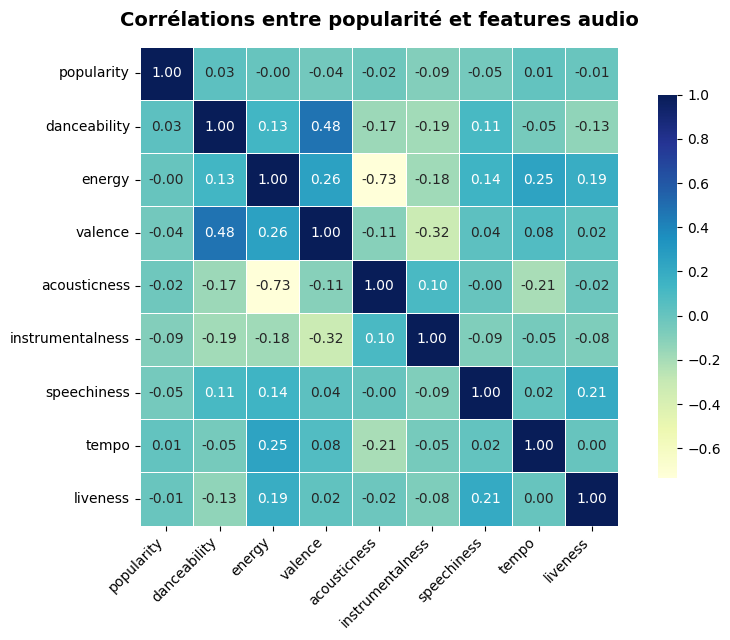

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_pd = df_clean.select(
    "popularity",
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "speechiness",
    "tempo",
    "liveness"
).toPandas()

corr_matrix = corr_pd.corr(numeric_only=True)

plt.figure(figsize=(9, 6.5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Corrélations entre popularité et features audio", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

La heatmap permet d’identifier les relations entre les variables audio.
On observe notamment quelles features sont les plus liées à la popularité.
Par exemple, la popularité semble davantage associée à certaines caractéristiques
comme la danceability ou l’energy qu’à des variables comme l’instrumentalness.

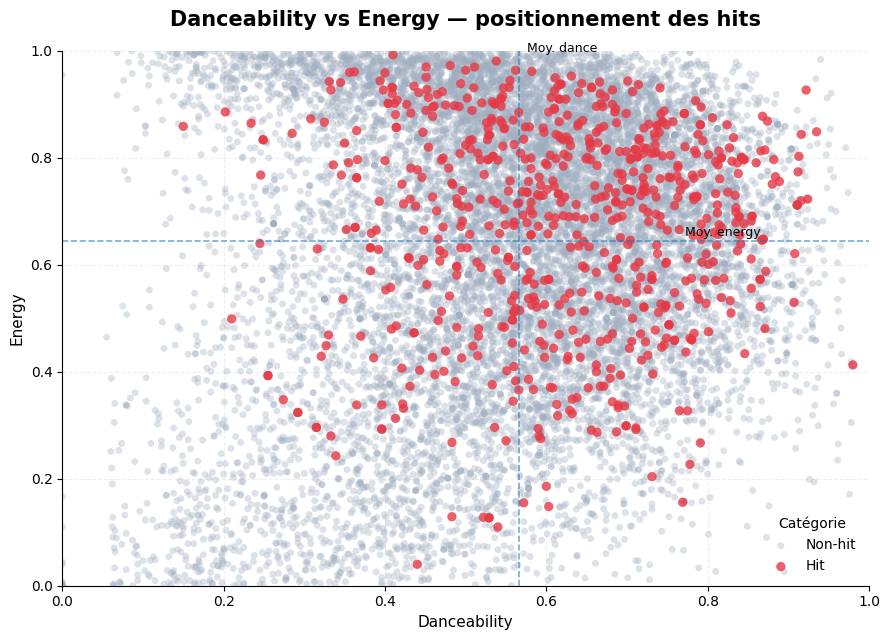

In [81]:
import matplotlib.pyplot as plt
import numpy as np

scatter_pd = (
    df_clean
    .select("danceability", "energy", "popularity")
    .sample(withReplacement=False, fraction=0.12, seed=42)
    .toPandas()
    .copy()
)

# Catégorisation
scatter_pd["categorie"] = np.where(scatter_pd["popularity"] >= 70, "Hit", "Non-hit")

fig, ax = plt.subplots(figsize=(9, 6.5))

# Couleurs cohérentes
colors = {"Non-hit": "#a0aec0", "Hit": "#e63946"}

for categorie in ["Non-hit", "Hit"]:
    subset = scatter_pd[scatter_pd["categorie"] == categorie]
    ax.scatter(
        subset["danceability"],
        subset["energy"],
        label=categorie,
        alpha=0.35 if categorie == "Non-hit" else 0.8,
        s=25 if categorie == "Non-hit" else 45,
        c=colors[categorie],
        edgecolors="none"
    )

# Moyennes (repères visuels)
mean_dance = scatter_pd["danceability"].mean()
mean_energy = scatter_pd["energy"].mean()

ax.axvline(mean_dance, linestyle="--", linewidth=1.2, alpha=0.6)
ax.axhline(mean_energy, linestyle="--", linewidth=1.2, alpha=0.6)

# Annotation discrète
ax.text(mean_dance + 0.01, ax.get_ylim()[1]*0.95, "Moy. dance", fontsize=9)
ax.text(ax.get_xlim()[1]*0.75, mean_energy + 0.01, "Moy. energy", fontsize=9)

# Titres
ax.set_title("Danceability vs Energy — positionnement des hits",
             fontsize=15, fontweight="bold", pad=18)
ax.set_xlabel("Danceability", fontsize=11)
ax.set_ylabel("Energy", fontsize=11)

# Limites propres
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Grille subtile
ax.grid(True, linestyle="--", alpha=0.2)
ax.set_axisbelow(True)

# Nettoyage
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.legend(title="Catégorie", frameon=False)

plt.tight_layout()
plt.show()

Ce graphique montre où se situent les hits dans l’espace sonore.
On observe que les morceaux très populaires se concentrent souvent
dans des zones plus dansantes et plus énergétiques,
ce qui confirme les tendances déjà vues dans l’analyse comparative hits / non-hits.

C:\Users\canpe\AppData\Local\Temp\ipykernel_23668\1947686861.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


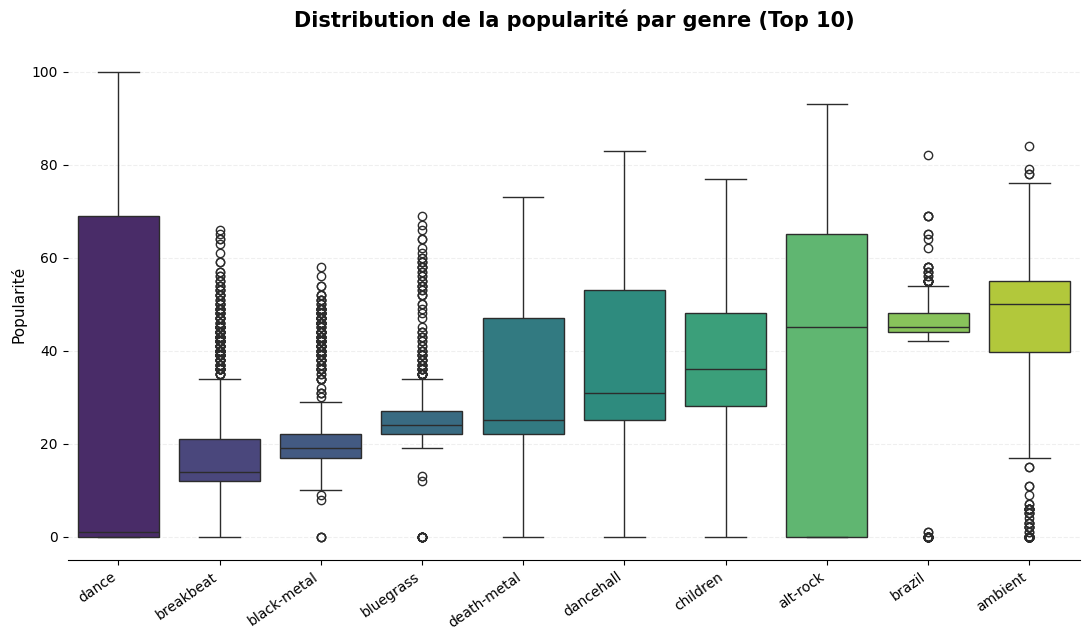

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 genres
top_genres_pd = (
    df_clean.groupBy("track_genre")
    .count()
    .orderBy("count", ascending=False)
    .limit(10)
    .toPandas()
)

top_genres_list = top_genres_pd["track_genre"].tolist()

# Dataset filtré
box_pd = (
    df_clean
    .filter(df_clean["track_genre"].isin(top_genres_list))
    .select("track_genre", "popularity")
    .toPandas()
)

# Ordonner les genres par médiane de popularité
order = (
    box_pd.groupby("track_genre")["popularity"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(11, 6.5))

# Palette élégante
palette = sns.color_palette("viridis", len(order))

ax = sns.boxplot(
    data=box_pd,
    x="track_genre",
    y="popularity",
    order=order,
    palette=palette,
    linewidth=1
)

# Amélioration visuelle
sns.despine(left=True)

ax.set_title("Distribution de la popularité par genre (Top 10)",
             fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("")
ax.set_ylabel("Popularité", fontsize=11)

# Rotation + lisibilité
plt.xticks(rotation=35, ha="right")

# Grille subtile
ax.grid(axis="y", linestyle="--", alpha=0.2)
ax.set_axisbelow(True)

# Ajustement des marges
plt.tight_layout()
plt.show()

Ce graphique montre que certains genres présentent une forte dispersion de popularité,
avec quelques hits très élevés mais beaucoup de morceaux peu populaires.

D’autres genres ont une popularité plus homogène,
ce qui indique une performance plus stable mais moins de hits majeurs.

## 🤖 Partie 5 — Machine Learning (bonus)

Nous appliquons un modèle de **clustering K-Means** pour regrouper les chansons selon leur profil audio.

Objectif :
- identifier des groupes de morceaux similaires
- explorer des profils musicaux types à partir de variables numériques

In [87]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql import functions as F

# Features audio retenues
ml_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "speechiness",
    "liveness",
    "tempo"
]

# Vérification des nulls sur les colonnes ML
df_ml_base = df_clean.dropna(subset=ml_features)

print(f"Nombre de lignes utilisées pour le ML : {df_ml_base.count():,}")

# Assemblage des variables dans un vecteur
assembler = VectorAssembler(inputCols=ml_features, outputCol="features_raw")
df_ml = assembler.transform(df_ml_base)

# Standardisation (important car tempo n'est pas sur la même échelle que les autres)
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)
scaler_model = scaler.fit(df_ml)
df_ml = scaler_model.transform(df_ml)

df_ml.select("features_raw", "features").show(3, truncate=False)

Nombre de lignes utilisées pour le ML : 113,865
+-----------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features_raw                                         |features                                                                                                                                                         |
+-----------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[0.676,0.461,0.715,0.0322,1.01E-6,0.143,0.358,87.917]|[0.6282545283139482,-0.7201062690098301,0.9287264318403574,-0.8493259663425548,-0.503736324320381,0.551611187445166,0.7586489243117458,-1.1427331880938718]      |
|[0.42,0.166,0.267,0.924,5.56E-6,0.0763,0.101,77.489] |[-0.8479124919219319,-1.8

In [88]:
from pyspark.ml.clustering import KMeans

# Choix simple : 3 clusters
kmeans = KMeans(
    k=3,
    seed=42,
    featuresCol="features",
    predictionCol="cluster"
)

model = kmeans.fit(df_ml)
df_clustered = model.transform(df_ml)

print("✅ Modèle K-Means entraîné")
print(f"Inertia / coût du modèle : {model.summary.trainingCost:.2f}")

df_clustered.select("cluster").groupBy("cluster").count().orderBy("cluster").show()

✅ Modèle K-Means entraîné
Inertia / coût du modèle : 667637.59
+-------+-----+
|cluster|count|
+-------+-----+
|      0|77690|
|      1| 5935|
|      2|30240|
+-------+-----+



In [89]:
cluster_profile = (
    df_clustered
    .groupBy("cluster")
    .agg(
        F.count("*").alias("nb_chansons"),
        F.round(F.avg("danceability"), 3).alias("danceability_moy"),
        F.round(F.avg("energy"), 3).alias("energy_moy"),
        F.round(F.avg("valence"), 3).alias("valence_moy"),
        F.round(F.avg("acousticness"), 3).alias("acousticness_moy"),
        F.round(F.avg("instrumentalness"), 3).alias("instrumentalness_moy"),
        F.round(F.avg("speechiness"), 3).alias("speechiness_moy"),
        F.round(F.avg("liveness"), 3).alias("liveness_moy"),
        F.round(F.avg("tempo"), 1).alias("tempo_moy"),
        F.round(F.avg("popularity"), 1).alias("popularite_moy")
    )
    .orderBy("cluster")
)

cluster_profile.show(truncate=False)

+-------+-----------+----------------+----------+-----------+----------------+--------------------+---------------+------------+---------+--------------+
|cluster|nb_chansons|danceability_moy|energy_moy|valence_moy|acousticness_moy|instrumentalness_moy|speechiness_moy|liveness_moy|tempo_moy|popularite_moy|
+-------+-----------+----------------+----------+-----------+----------------+--------------------+---------------+------------+---------+--------------+
|0      |77690      |0.596           |0.762     |0.527      |0.147           |0.123               |0.072          |0.221       |127.0    |33.7          |
|1      |5935       |0.655           |0.677     |0.526      |0.369           |0.031               |0.434          |0.321       |119.1    |32.3          |
|2      |30240      |0.477           |0.326     |0.328      |0.732           |0.266               |0.048          |0.174       |110.4    |32.2          |
+-------+-----------+----------------+----------+-----------+---------------

### Interprétation des clusters

Le clustering met en évidence plusieurs profils de chansons :

- un groupe de morceaux plus énergiques et dansants
- un groupe plus acoustique ou instrumental
- un groupe intermédiaire avec des caractéristiques plus équilibrées

Cette segmentation montre que le catalogue Spotify peut être structuré automatiquement
à partir des seules features audio.

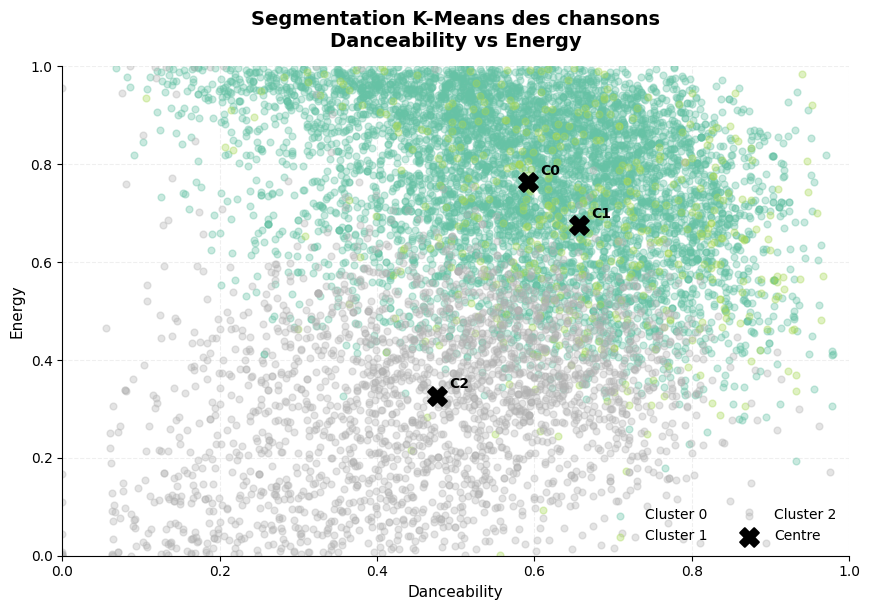

In [93]:
cluster_pd = (
    df_clustered
    .select("danceability", "energy", "cluster")
    .sample(withReplacement=False, fraction=0.08, seed=42)
    .toPandas()
    .copy()
)

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8.8, 6.2))

clusters = sorted(cluster_pd["cluster"].unique())
colors = plt.cm.Set2(np.linspace(0, 1, len(clusters)))

# Nuage de points par cluster
for i, c in enumerate(clusters):
    subset = cluster_pd[cluster_pd["cluster"] == c]
    ax.scatter(
        subset["danceability"],
        subset["energy"],
        s=24,
        alpha=0.35,
        color=colors[i],
        label=f"Cluster {c}"
    )

# Centres moyens des clusters
centers = cluster_pd.groupby("cluster")[["danceability", "energy"]].mean()

ax.scatter(
    centers["danceability"],
    centers["energy"],
    s=180,
    color="black",
    marker="X",
    linewidths=1.5,
    zorder=4,
    label="Centre"
)

# Annotations des centres
for cluster_id, row in centers.iterrows():
    ax.text(
        row["danceability"] + 0.015,
        row["energy"] + 0.015,
        f"C{cluster_id}",
        fontsize=10,
        fontweight="bold"
    )

# Titres et axes
ax.set_title(
    "Segmentation K-Means des chansons\nDanceability vs Energy",
    fontsize=14,
    fontweight="bold",
    pad=14
)
ax.set_xlabel("Danceability", fontsize=11)
ax.set_ylabel("Energy", fontsize=11)

# Limites logiques
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Grille légère
ax.grid(True, linestyle="--", alpha=0.2)
ax.set_axisbelow(True)

# Nettoyage visuel
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

Le clustering met en évidence plusieurs profils de morceaux.
Certains clusters regroupent des chansons plus énergiques et dansantes,
tandis que d’autres correspondent à des titres plus calmes ou plus équilibrés.

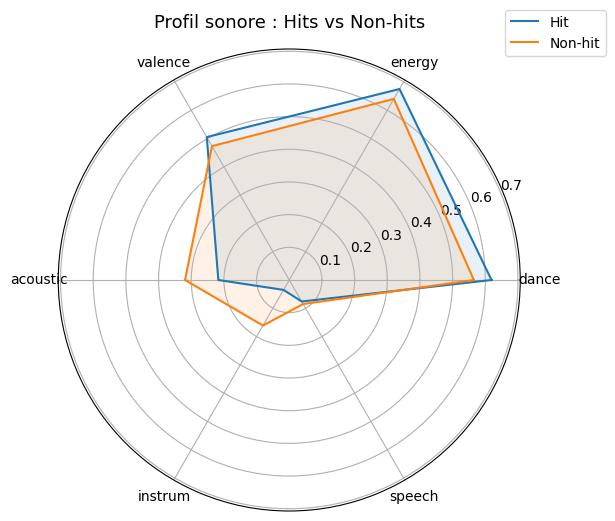

In [96]:
import matplotlib.pyplot as plt
import numpy as np

radar_pd = features_comparison.toPandas().copy()

# Harmonisation labels
radar_pd["is_hit"] = radar_pd["is_hit"].replace({
    "Hit (pop>70)": "Hit",
    "Non-hit": "Non-hit"
})

features = ["dance", "energy", "valence", "acoustic", "instrum", "speech"]

angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

for _, row in radar_pd.iterrows():
    values = row[features].tolist()
    values += values[:1]
    
    ax.plot(angles, values, label=row["is_hit"])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features)

ax.set_title("Profil sonore : Hits vs Non-hits", fontsize=13, pad=15)
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

plt.show()

Les hits sont globalement plus dynamiques (dance, energy).

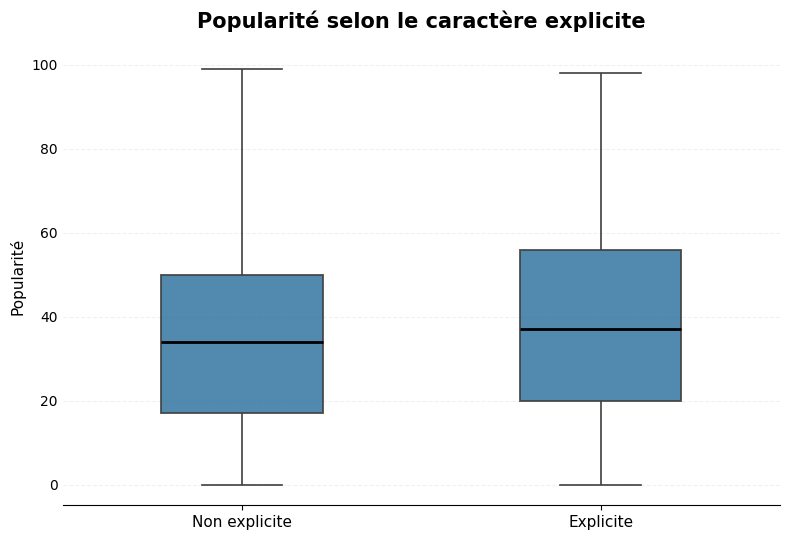

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

box_pd = df_clean.select("explicit", "popularity").toPandas().copy()

# Labels propres
box_pd["explicit"] = box_pd["explicit"].replace({
    True: "Explicite",
    False: "Non explicite",
    1: "Explicite",
    0: "Non explicite"
})

order = ["Non explicite", "Explicite"]

plt.figure(figsize=(8, 5.5))

ax = sns.boxplot(
    data=box_pd,
    x="explicit",
    y="popularity",
    order=order,
    width=0.45,
    linewidth=1.4,
    showfliers=False,
    boxprops=dict(alpha=0.85),
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2)
)

ax.set_title(
    "Popularité selon le caractère explicite",
    fontsize=15,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("")
ax.set_ylabel("Popularité", fontsize=11)

# Style plus clean
ax.grid(axis="y", linestyle="--", alpha=0.18)
ax.set_axisbelow(True)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", labelsize=11)

plt.tight_layout()
plt.show()

Les morceaux explicites ont une médiane légèrement plus élevée.

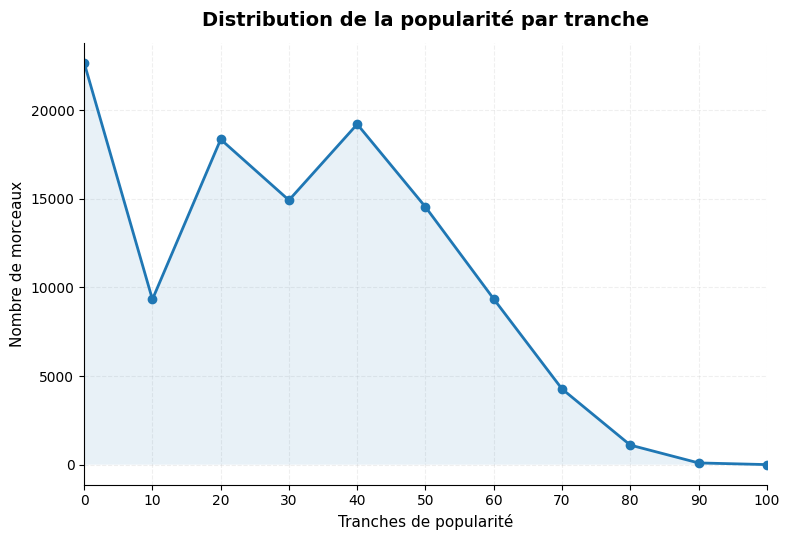

In [102]:
import matplotlib.pyplot as plt

bucket_pd = (
    df_clean
    .withColumn(
        "pop_bucket",
        (df_clean["popularity"]/10).cast("int")*10
    )
    .groupBy("pop_bucket")
    .count()
    .orderBy("pop_bucket")
    .toPandas()
)

fig, ax = plt.subplots(figsize=(8, 5.5))

# Courbe améliorée
ax.plot(
    bucket_pd["pop_bucket"],
    bucket_pd["count"],
    marker="o",
    linewidth=2,
    markersize=6
)

# Remplissage léger sous la courbe
ax.fill_between(
    bucket_pd["pop_bucket"],
    bucket_pd["count"],
    alpha=0.1
)

# Titres
ax.set_title(
    "Distribution de la popularité par tranche",
    fontsize=14,
    fontweight="bold",
    pad=12
)
ax.set_xlabel("Tranches de popularité", fontsize=11)
ax.set_ylabel("Nombre de morceaux", fontsize=11)

# Axes propres
ax.set_xticks(bucket_pd["pop_bucket"])
ax.set_xlim(bucket_pd["pop_bucket"].min(), bucket_pd["pop_bucket"].max())

# Grille subtile
ax.grid(True, linestyle="--", alpha=0.2)
ax.set_axisbelow(True)

# Nettoyage
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Forte concentration dans les basses popularités.

Le modèle K-Means permet de regrouper les chansons selon leurs caractéristiques audio.
On obtient ainsi plusieurs profils de morceaux (énergétiques, acoustiques, etc.).

In [103]:
df_clustered.groupBy("cluster").agg(
    F.count("*").alias("nb"),
    F.round(F.avg("popularity"), 1).alias("pop_moy")
).orderBy("cluster").show()

+-------+-----+-------+
|cluster|   nb|pop_moy|
+-------+-----+-------+
|      0|77690|   33.7|
|      1| 5935|   32.3|
|      2|30240|   32.2|
+-------+-----+-------+



In [104]:
for k in [2, 3, 4, 5]:
    model = KMeans(k=k, seed=42, featuresCol="features").fit(df_ml)
    print(f"k={k} → coût = {model.summary.trainingCost:.2f}")

k=2 → coût = 737098.95
k=3 → coût = 667637.59
k=4 → coût = 596538.60
k=5 → coût = 530490.11


Le clustering permet de segmenter automatiquement le catalogue Spotify
en plusieurs profils musicaux distincts à partir des seules features audio.

On observe ainsi une opposition entre :
- des morceaux dynamiques et dansants
- des morceaux plus calmes et acoustiques
- des morceaux intermédiaires

Cela montre que les caractéristiques audio sont suffisantes
pour structurer le catalogue de manière cohérente.

Les visualisations réalisées permettent de mieux comprendre la structure du catalogue Spotify et les facteurs liés à la popularité des morceaux.

Les graphiques montrent que la popularité est fortement concentrée sur un petit nombre de titres, confirmant un effet de "long tail".  
Les comparaisons entre hits et non-hits mettent en évidence que les morceaux les plus populaires sont en moyenne plus dansants et légèrement plus énergiques.

L’analyse par genre révèle également des différences importantes, certains styles générant davantage de succès que d’autres.  
Enfin, les visualisations plus avancées (scatter, boxplot, clustering) permettent d’identifier des profils musicaux distincts et de mieux comprendre le positionnement des morceaux.

Dans l’ensemble, ces graphiques apportent une lecture claire et complémentaire des données, en facilitant l’interprétation des résultats obtenus précédemment.

Ce projet a permis d’analyser un large dataset de chansons Spotify en utilisant PySpark, depuis l’ingestion des données jusqu’à leur interprétation.

Après un nettoyage rigoureux (gestion des types, des valeurs manquantes et des doublons), nous avons réalisé une analyse exploratoire mettant en évidence plusieurs tendances :
- une forte concentration de la popularité sur un petit nombre de morceaux
- des différences entre genres musicaux
- un profil spécifique des chansons les plus populaires (plus dansantes et énergétiques)

Les transformations avancées (jointures, agrégations, fonctions de fenêtre) ont permis d’enrichir les analyses et d’extraire des insights plus fins.  
Les optimisations (cache, broadcast, analyse du plan d’exécution) ont montré l’importance d’adapter les techniques au volume de données.

Les visualisations ont rendu ces résultats plus lisibles et ont confirmé les tendances observées.  
Enfin, l’utilisation d’un modèle de clustering (K-Means) a permis d’identifier différents profils musicaux au sein du catalogue.

Ce projet illustre ainsi la capacité de PySpark à traiter efficacement des données structurées et à produire des analyses exploitables, tout en mettant en évidence l’importance de l’interprétation des résultats.